In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import (
    KMeans,
    MeanShift
)
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold      import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

from Transformers import *  
from prince import FAMD
import warnings
warnings.filterwarnings("ignore")
import pickle
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN  
import gower
from sklearn.manifold import TSNE


## Wczytanie danych

Wczytujemy dane po preprocessingu i przetwarzamy je ponownie przy pomocą FAMD lub odległości Gowera

In [3]:
df_train=pd.read_csv("data/TransformedData/train.csv")
df_test=pd.read_csv("data/TransformedData/test.csv") 

In [4]:
def load_famd(filepath: str):
    with open(filepath, 'rb') as f:
        famd = pickle.load(f)
    print(f"FAMD model loaded from {filepath!r}")
    return famd

In [5]:
Famd= load_famd("data/TransformedData/famd_model.pkl")
X_test= Famd.transform(df_test)
X_train= Famd.transform(df_train)

FAMD model loaded from 'data/TransformedData/famd_model.pkl'


In [6]:
X_train_gower = gower.gower_matrix(df_train)
X_test_gower = gower.gower_matrix(df_test)

In [7]:
df_raw_test = pd.read_csv("data/SplitRawData/test.csv")

## T-SNE plot function

funkcja przyjmuje dane, wykonuje na nich T-SNE i wizualizuje wyniki

In [8]:
def tsne_plot(
    X, 
    y, 
    title: str = "t-SNE",
    perplexity: float = 30.0,
    random_state: int = 42,
    point_size: int = 40,
    cmap: str = "tab10"
):
    
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state
    )
    X_emb = tsne.fit_transform(X)
    
   
    plt.figure(figsize=(7, 5))
    sc = plt.scatter(
        X_emb[:, 0], X_emb[:, 1], 
        c=y, 
        cmap=cmap, 
        s=point_size, 
        alpha=0.8,
        edgecolor="k",
        linewidth=0.2
    )
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    if title:
        plt.title(title)
    
   
    labels_unique = np.unique(y)

    handles = []
    for lab in labels_unique:
        handles.append(
            plt.Line2D(
                [], [], marker="o", ls="", 
                color=sc.cmap(sc.norm(lab)), 
                label=str(lab),
                markeredgecolor="k", 
                markersize=6
            )
        )
    plt.legend(
        handles=handles, 
        title="cluster", 
        bbox_to_anchor=(1.05, 1), 
        loc="upper left"
    )
    plt.tight_layout()
    plt.show()


# Algorytmy klasteryzacji dla ustalonych wcześniej parametrów (liczba klastrów / eps / bindwidth)

## KMeans Clustering - wraz z interpretacją

Train

In [25]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_train)
predicted_train = kmeans.predict(X_train)

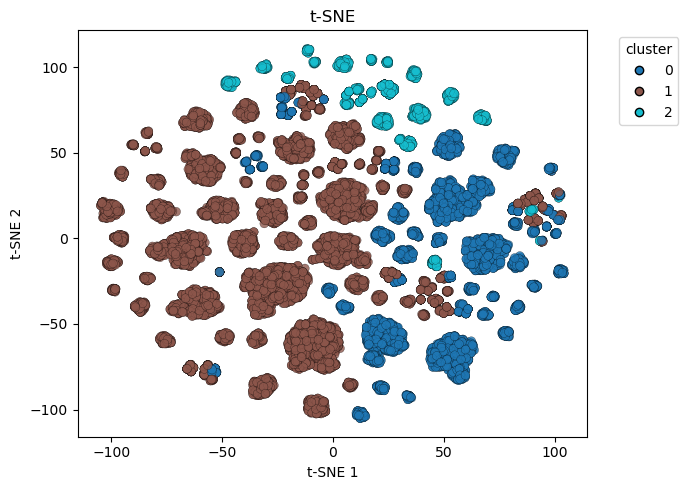

In [26]:
tsne_plot(X_train,y=predicted_train)

Test

In [27]:
predicted_test=kmeans.predict(X_test)

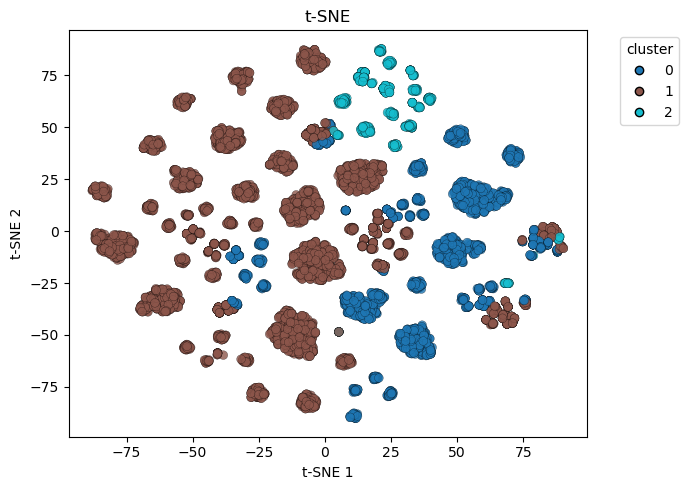

In [28]:
tsne_plot(X_test,y=predicted_test)

Z ciekawości zbadamy zależności kryjące się w tym podziale, jednak generalnie podział uznajemy za słaby

In [29]:
rf = RandomForestClassifier(random_state=42)
rf.fit(df_test, predicted_test)
feat_importances = pd.Series(rf.feature_importances_, index=df_test.columns).sort_values(ascending=False)

Na razie nie wygląda obiecująco

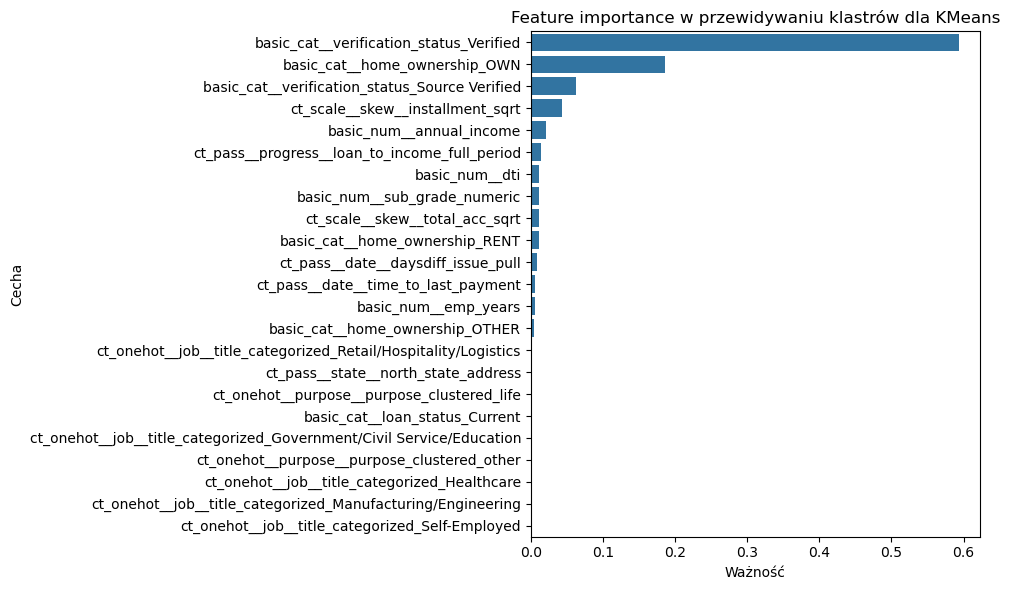

In [30]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importances, y=feat_importances.index)
plt.title("Feature importance w przewidywaniu klastrów dla KMeans")
plt.xlabel("Ważność")
plt.ylabel("Cecha")
plt.tight_layout()
plt.show()

In [31]:
KM_raw_labels = pd.concat([df_raw_test, pd.DataFrame(predicted_test)], axis=1).rename(columns={0: "cluster"})

In [32]:
numeric_cols = df_raw_test.select_dtypes(include=["float64", "int64"]).columns
numeric_cols

Index(['annual_income', 'dti', 'installment', 'int_rate', 'loan_amount',
       'total_acc', 'total_payment', 'emp_years', 'grade_numeric',
       'sub_grade_numeric', 'issue_year', 'issue_month', 'issue_day',
       'issue_weekday', 'last_credit_pull_year', 'last_credit_pull_month',
       'last_credit_pull_day', 'last_credit_pull_weekday', 'last_payment_year',
       'last_payment_month', 'last_payment_day', 'last_payment_weekday',
       'next_payment_year', 'next_payment_month', 'next_payment_day',
       'next_payment_weekday', 'term_months'],
      dtype='object')

Wyindukował się podział względem kwot dochodów oraz kredytów, jednak niejednoznaczny - największe kredyty płacą najmniejsze raty (?)

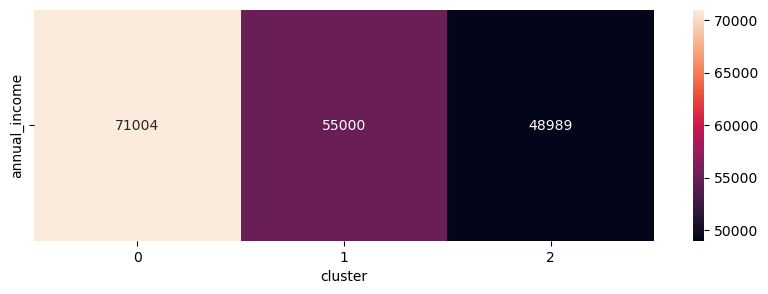

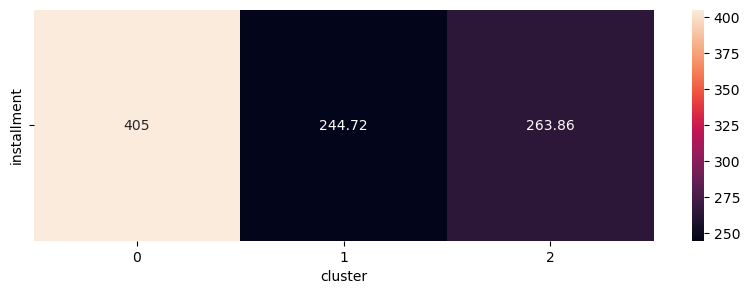

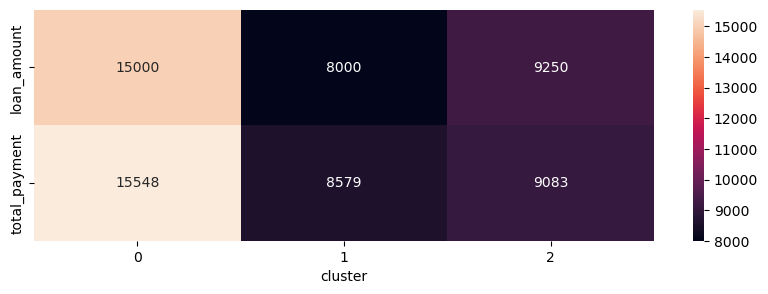

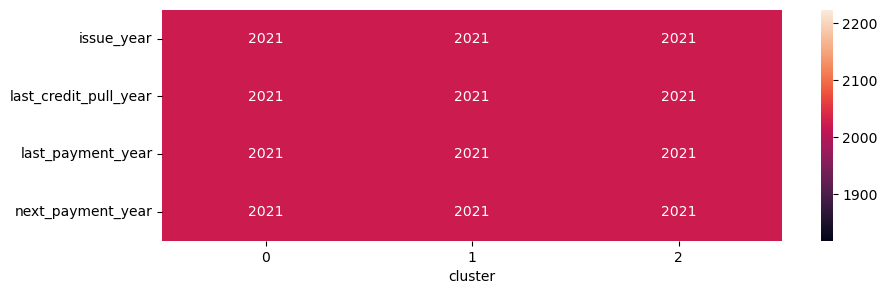

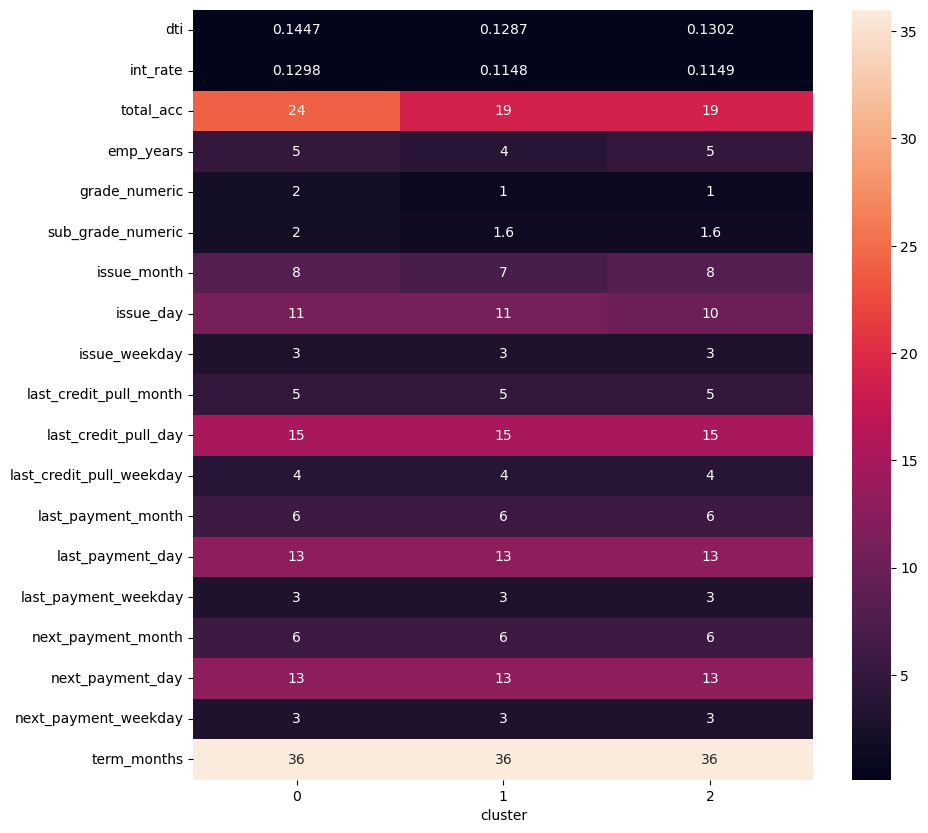

In [33]:
plt.figure(figsize=(10,3))
sns.heatmap(KM_raw_labels[['annual_income', 'cluster']].groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()
plt.figure(figsize=(10,3))
sns.heatmap(KM_raw_labels[['installment', 'cluster']].groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()
plt.figure(figsize=(10,3))
sns.heatmap(KM_raw_labels[['loan_amount', 'total_payment', 'cluster']].groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()
plt.figure(figsize=(10,3))
sns.heatmap(KM_raw_labels[['issue_year', 'last_credit_pull_year', 'last_payment_year', 'next_payment_year', 'cluster']].groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()
plt.figure(figsize=(10,10))
sns.heatmap(KM_raw_labels.drop(columns=['annual_income', 'installment', 'loan_amount', 'total_payment', 'issue_year', 'last_credit_pull_year', 'last_payment_year', 'next_payment_year']).groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()

In [34]:
cat_cols = ['home_ownership',
 'loan_status',
 'purpose',
 'verification_status']

Wystąpił również podział względem statusu własności domu/mieszkania, konsolidacji kredytu, przeznaczenia kredytu oraz weryfikacji kredytobiorcy


Wystąpienia dla cechy: home_ownership


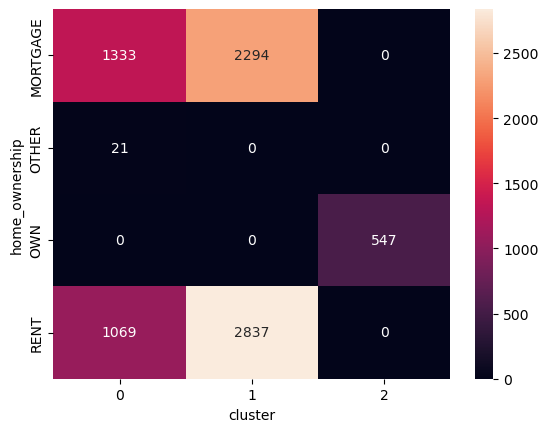


Wystąpienia dla cechy: loan_status


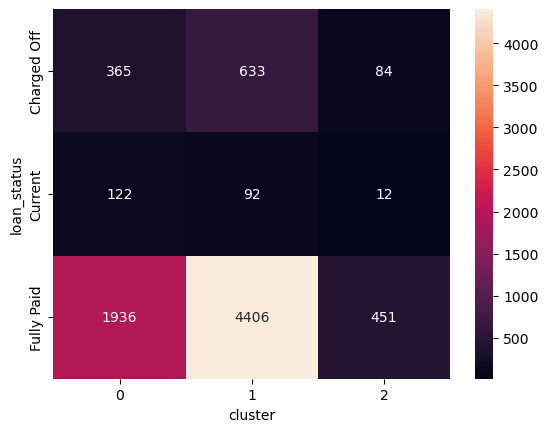


Wystąpienia dla cechy: purpose


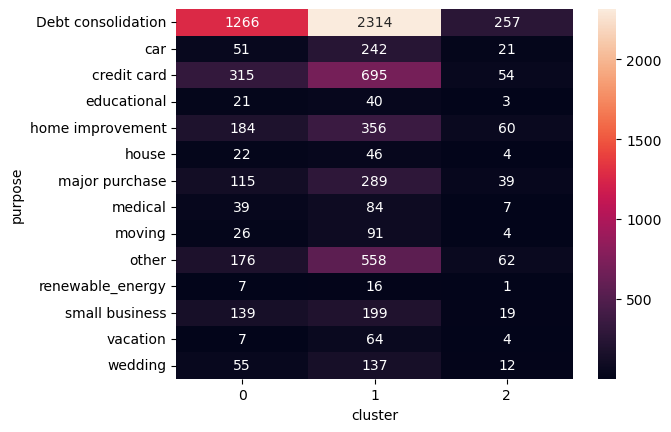


Wystąpienia dla cechy: verification_status


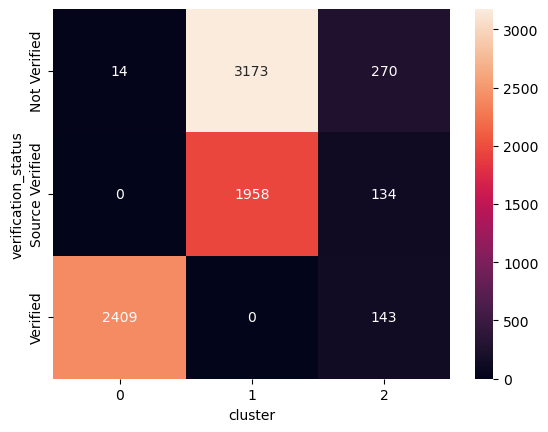

In [35]:
for col in cat_cols:
    print(f"\nWystąpienia dla cechy: {col}")
    crosstab = pd.crosstab(KM_raw_labels[col], KM_raw_labels['cluster'])
    sns.heatmap(crosstab, annot=True, fmt='g')
    plt.show()


!!! Wnioski - podział jest niejednoznaczny, odrzucamy wyniki z tego modelu

## Mean shift

Train

In [36]:
ms = MeanShift(bandwidth=15, n_jobs=-1)
ms.fit(X_train)
predicted_train = ms.labels_

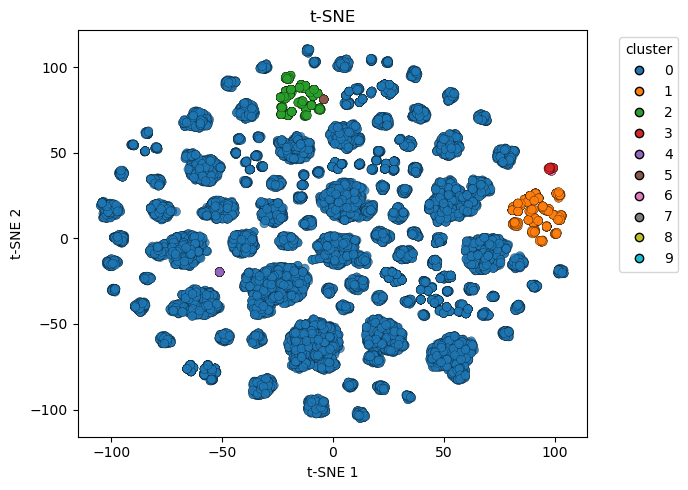

In [37]:
tsne_plot(X_train,y=predicted_train)

Test

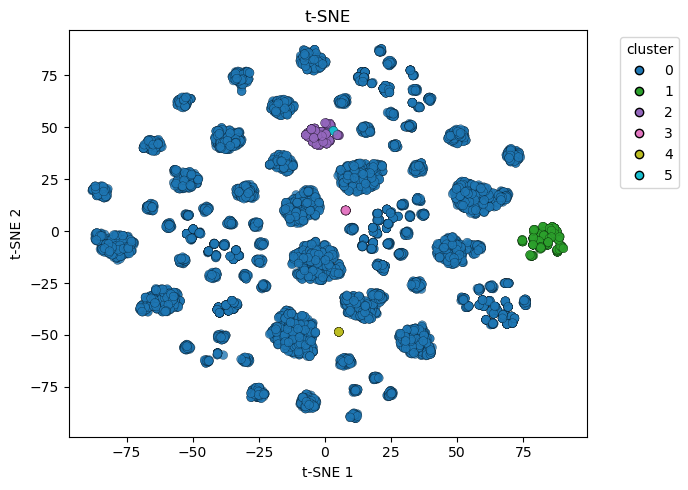

In [38]:
predicted_test = ms.predict(X_test)
tsne_plot(X_test,y=predicted_test)

Wyniki podobne co w KMeans, darujemy sobie dalszą analizę

## GMM - wraz z interpretacją - TEN WYKORZYSTAMY DO PREZENTACJI FINALNEJ

Train

In [65]:
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_train)
predicted_train = gmm.predict(X_train)


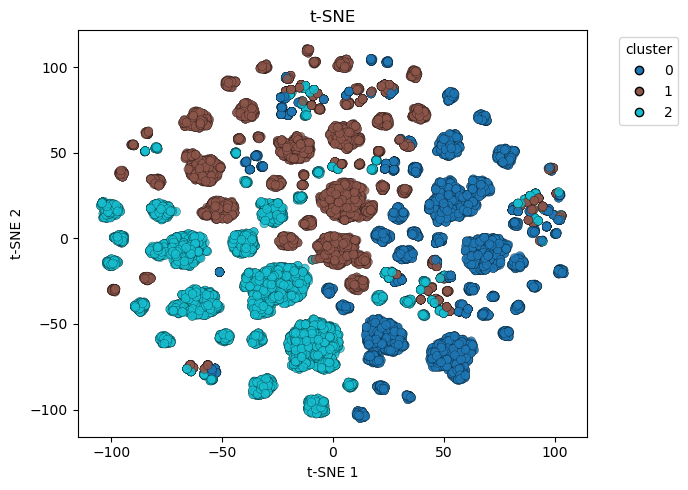

In [44]:
tsne_plot(X_train,y=predicted_train)

Test

In [66]:
predicted_test = gmm.predict(X_test)

In [46]:
with open("data/TransformedData/gmm_model.pkl", 'wb') as f:
    pickle.dump(gmm, f)

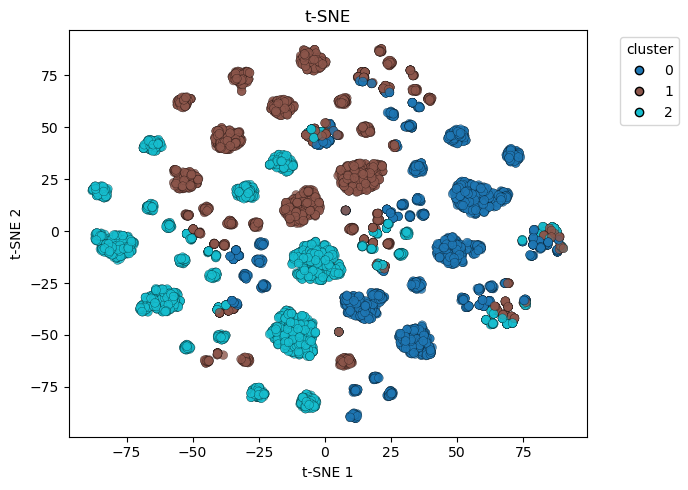

In [47]:
tsne_plot(X_test,y=predicted_test)

In [48]:
def inspect_gmm_parameters(gmm, feature_names=None):

    means = gmm.means_
    cov_type = gmm.covariance_type
    
    if cov_type == 'full':
        variances = np.array([np.diag(cov) for cov in gmm.covariances_])
    elif cov_type == 'tied':
        variances = np.tile(np.diag(gmm.covariances_), (gmm.n_components, 1))
    elif cov_type == 'diag':
        variances = gmm.covariances_
    elif cov_type == 'spherical':
        variances = np.tile(gmm.covariances_.reshape(-1,1), (1, gmm.means_.shape[1]))
    else:
        raise ValueError(f"Unknown covariance type: {cov_type}")

    n_components, n_features = means.shape
    if feature_names is None:
        feature_names = [f"feature_{i}" for i in range(n_features)]
    index = [f"component_{i}" for i in range(n_components)]

    df_means = pd.DataFrame(means, index=index, columns=feature_names)
    df_vars  = pd.DataFrame(variances, index=index, columns=feature_names)
    return df_means, df_vars

In [49]:
means_for_component, variances_for_component=inspect_gmm_parameters(gmm)
means_for_component

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20
component_0,3.839093,-0.692418,-0.431464,0.412238,-0.033147,-0.213836,0.160673,0.062839,-0.191592,-0.086122,...,-0.040148,0.104646,-1.449403,0.111275,-0.086233,-0.060934,0.009554,0.018287,-0.013440,-0.000201
component_1,-1.018202,2.620729,1.136626,-0.013215,-0.033032,0.103061,-0.121401,-0.081305,0.120588,0.178519,...,0.043641,1.110548,1.042680,-0.079335,-0.033330,0.006868,-0.031608,-0.020722,0.002285,0.013075
component_2,-2.652476,-1.889448,-0.694930,-0.377977,0.064764,0.100040,-0.034480,0.019732,0.064770,-0.091987,...,-0.003811,-1.175988,0.363459,-0.023955,0.125916,0.035615,0.025253,0.012036,0.004640,-0.002617


Nie wygląda to obiecująco, ale zobaczymy dalej

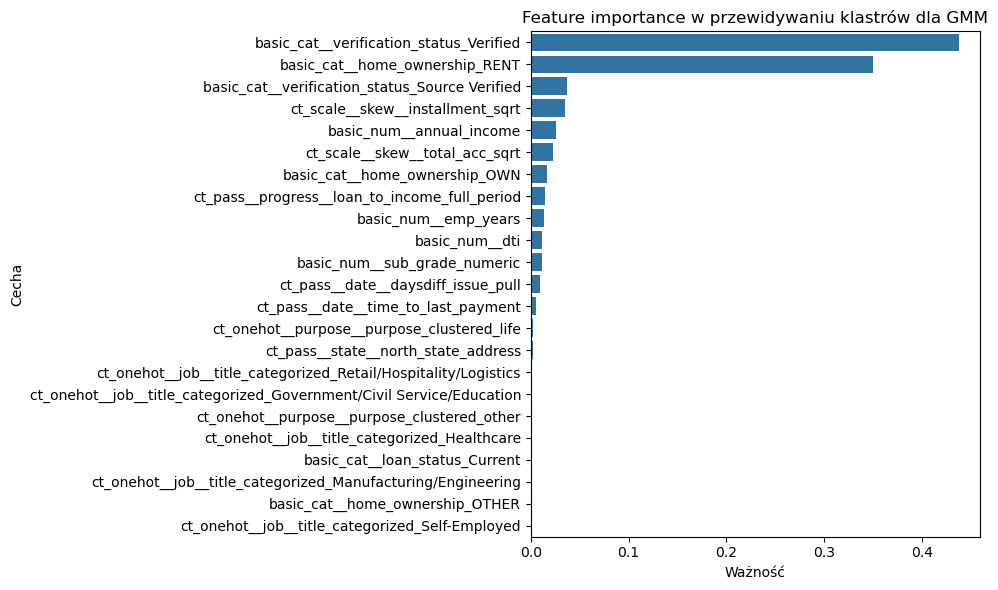

In [50]:
rf = RandomForestClassifier(random_state=42)
rf.fit(df_test, predicted_test)
feat_importances = pd.Series(rf.feature_importances_, index=df_test.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importances, y=feat_importances.index)
plt.title("Feature importance w przewidywaniu klastrów dla GMM")
plt.xlabel("Ważność")
plt.ylabel("Cecha")
plt.tight_layout()
plt.show()

In [51]:
GMM_raw_labels = pd.concat([df_raw_test, pd.DataFrame(predicted_test)], axis=1).rename(columns={0: "cluster"})

In [52]:
numeric_cols = df_raw_test.select_dtypes(include=["float64", "int64"]).columns
numeric_cols

Index(['annual_income', 'dti', 'installment', 'int_rate', 'loan_amount',
       'total_acc', 'total_payment', 'emp_years', 'grade_numeric',
       'sub_grade_numeric', 'issue_year', 'issue_month', 'issue_day',
       'issue_weekday', 'last_credit_pull_year', 'last_credit_pull_month',
       'last_credit_pull_day', 'last_credit_pull_weekday', 'last_payment_year',
       'last_payment_month', 'last_payment_day', 'last_payment_weekday',
       'next_payment_year', 'next_payment_month', 'next_payment_day',
       'next_payment_weekday', 'term_months'],
      dtype='object')

Podział na klastry uwzględnia różnice w poziomie życia (dochód) oraz wysokości kredytu, w reszcie cech z poniższej komórki nie widać różnic

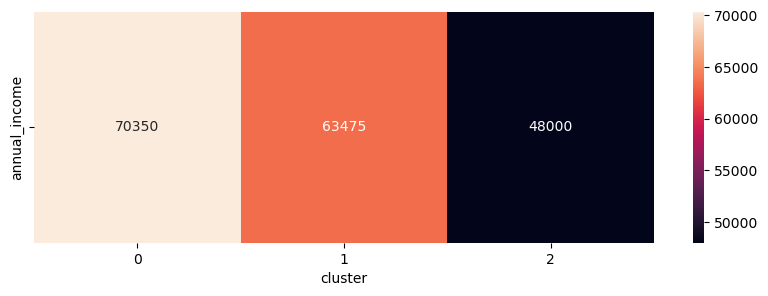

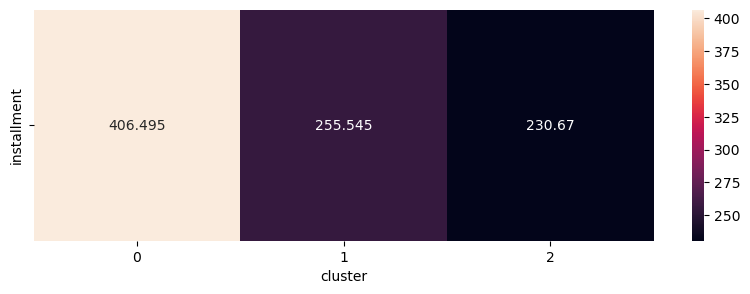

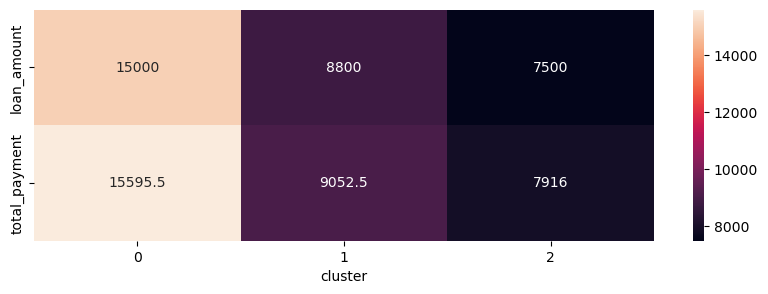

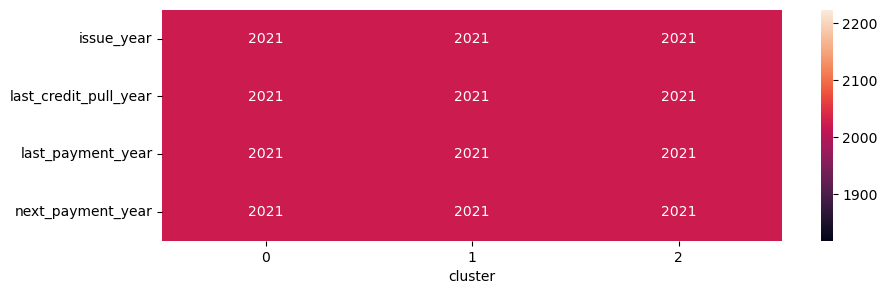

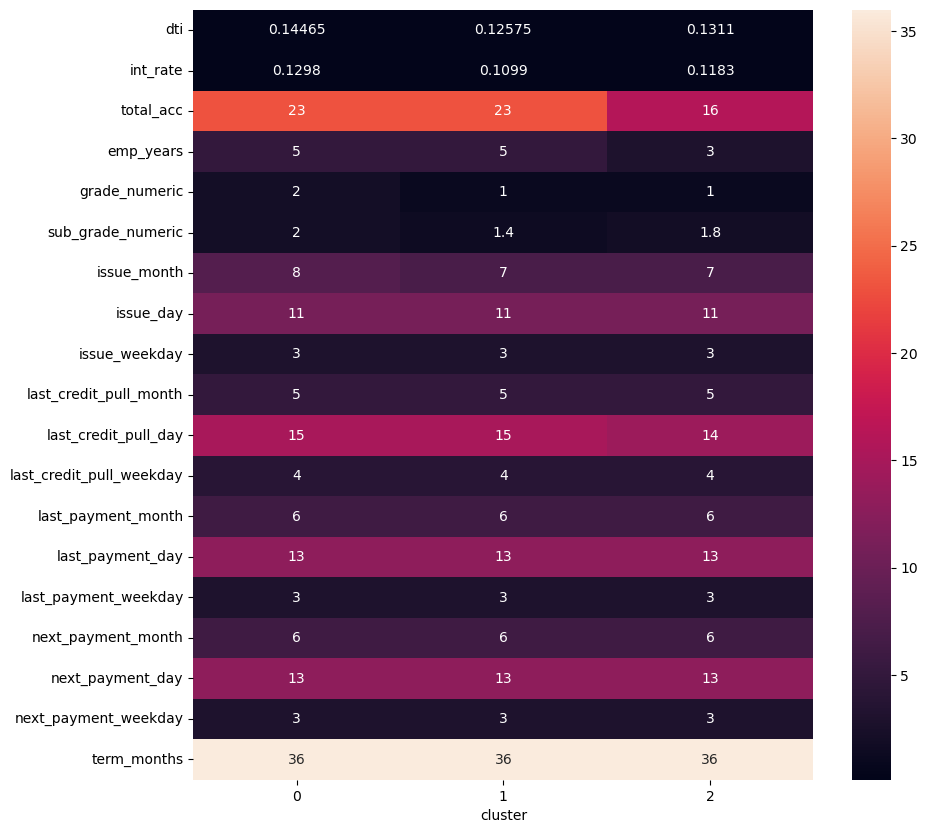

In [60]:
plt.figure(figsize=(10,3))
sns.heatmap(GMM_raw_labels[['annual_income', 'cluster']].groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()
plt.figure(figsize=(10,3))
sns.heatmap(GMM_raw_labels[['installment', 'cluster']].groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()
plt.figure(figsize=(10,3))
sns.heatmap(GMM_raw_labels[['loan_amount', 'total_payment', 'cluster']].groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()
plt.figure(figsize=(10,3))
sns.heatmap(GMM_raw_labels[['issue_year', 'last_credit_pull_year', 'last_payment_year', 'next_payment_year', 'cluster']].groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()
plt.figure(figsize=(10,10))
sns.heatmap(GMM_raw_labels.drop(columns=['annual_income', 'installment', 'loan_amount', 'total_payment', 'issue_year', 'last_credit_pull_year', 'last_payment_year', 'next_payment_year']).groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()

In [54]:
cat_cols = ['home_ownership',
 'loan_status',
 'purpose',
 'verification_status']

Klaster 0 - ludzie zarówno z wynajmowanymi domami/mieszkaniami, jak i hipotekami. Trochę kredytów na ulepszenia domów (remonty itd.). Wszystkie kredyty zweryfikowane.

Klaster 1 - ludzie głównie z hipotekami, trochę własnych domów/mieszkań. Trochę kredytów na ulepszenia domów (remonty itd.). Część kredytów niezweryfikowana.

Klaster 2 - całkowity wynajem. Więcej kredytów niż w pozostałych klastrach na kategorię "other". Część kredytów niezweryfikowana.


Wystąpienia dla cechy: home_ownership


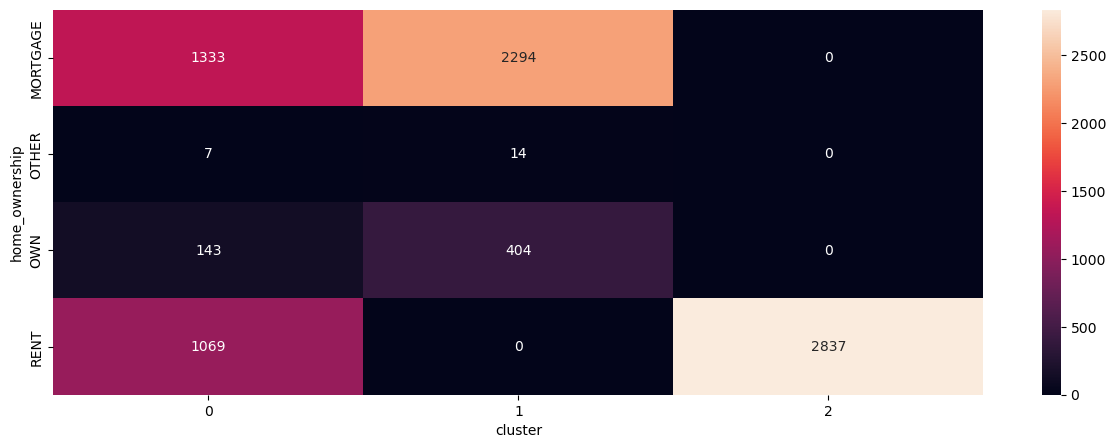


Wystąpienia dla cechy: loan_status


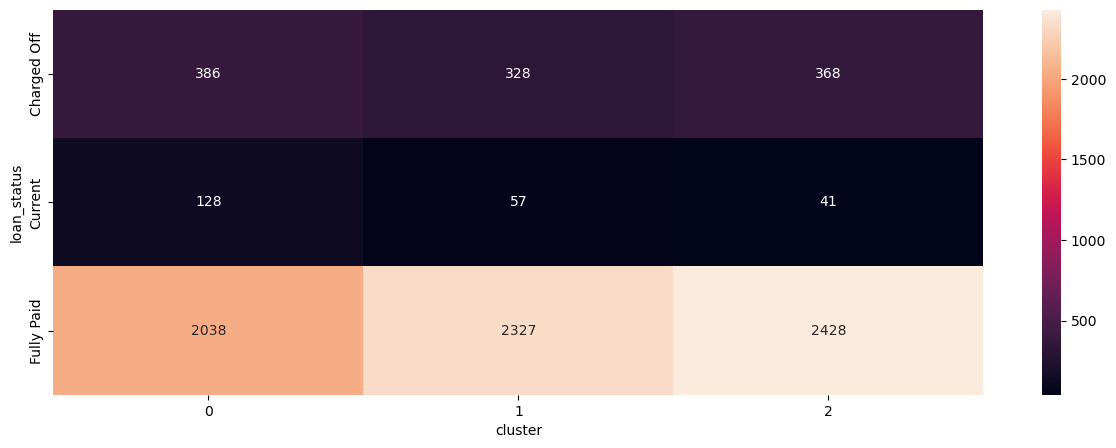


Wystąpienia dla cechy: purpose


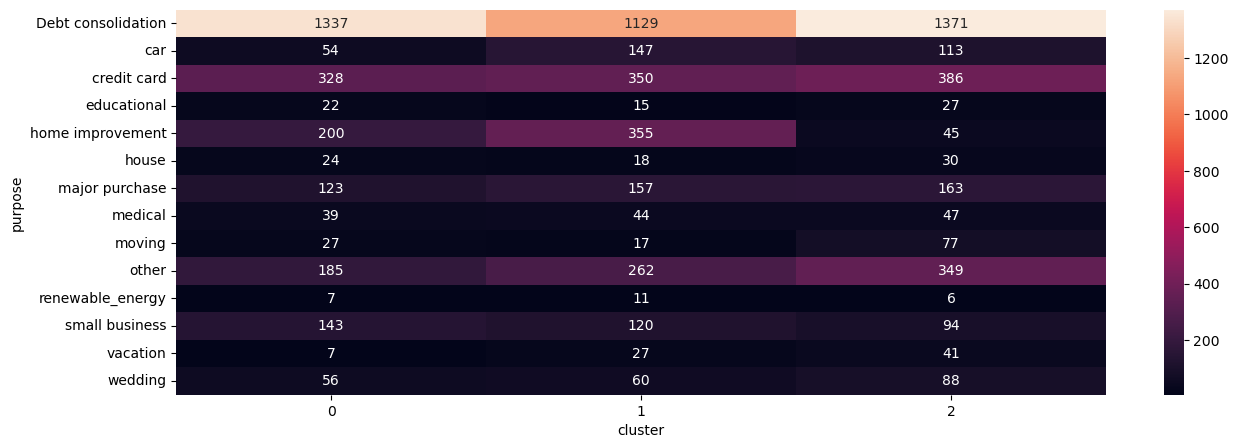


Wystąpienia dla cechy: verification_status


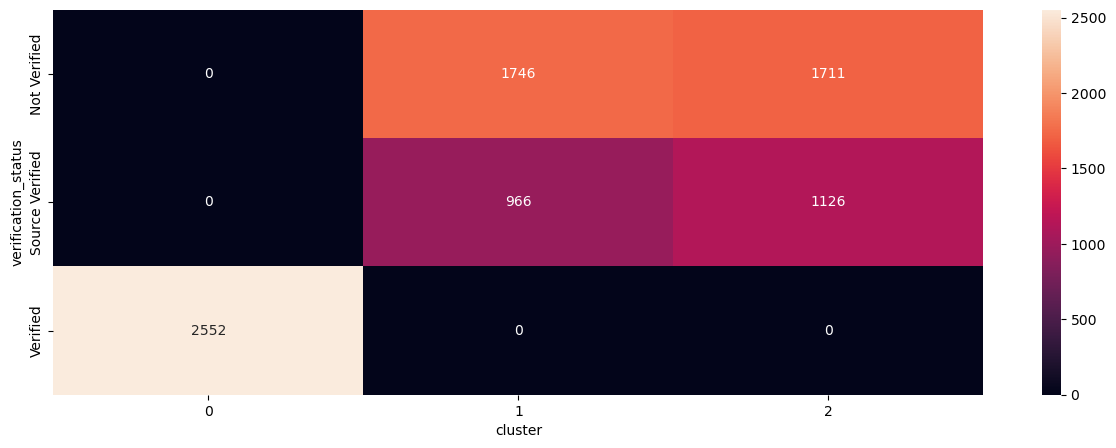

In [55]:
for col in cat_cols:
    print(f"\nWystąpienia dla cechy: {col}")
    crosstab = pd.crosstab(GMM_raw_labels[col], GMM_raw_labels['cluster'])
    plt.figure(figsize=(15,5))
    sns.heatmap(crosstab, annot=True, fmt='g')
    plt.show()


In [56]:
transf_with_labels = pd.concat([df_test, pd.Series(predicted_test)], axis=1).rename(columns={0: "cluster"})

Te same wnioski, co wcześniej

<Axes: xlabel='cluster'>

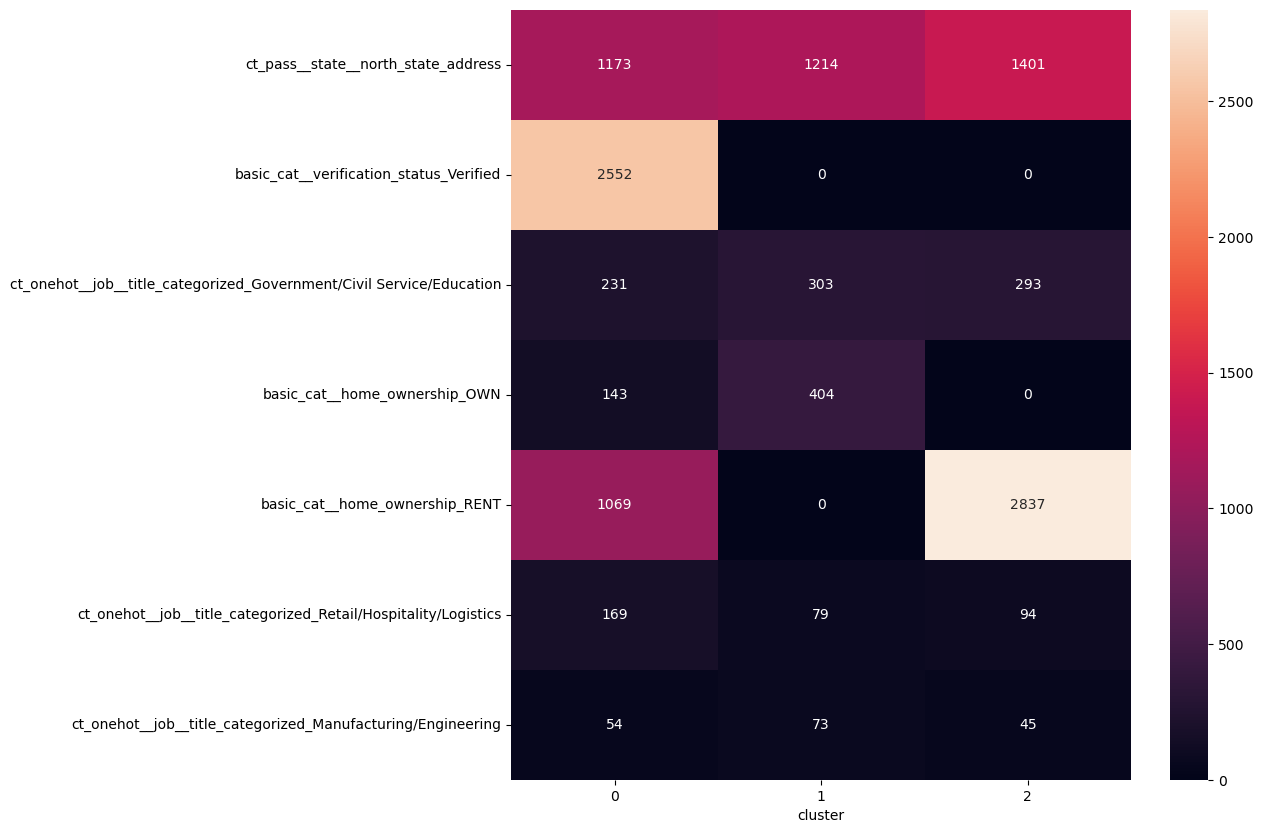

In [58]:
plt.figure(figsize=(10,10))
sns.heatmap(transf_with_labels[['ct_pass__state__north_state_address', 'basic_cat__verification_status_Verified',
                                'ct_onehot__job__title_categorized_Government/Civil Service/Education', 'basic_cat__home_ownership_OWN',
                                'basic_cat__home_ownership_RENT', 'ct_onehot__job__title_categorized_Retail/Hospitality/Logistics',
                                'ct_onehot__job__title_categorized_Manufacturing/Engineering', 'cluster']].groupby('cluster').sum().T, annot=True, fmt='g')

!!! Wnioski: sensowny podział:
* klaster 0 - największe kredyty, zarówno wynajmują jak i mają hipoteki, trochę kredytów na ulepszenia domów
* klaster 1 - ci po środku, znaczna większość hipoteki i trochę własnościowych domów/mieszkań, trochę kredytów na ulepszenia domów
* klaster 2 - ci z najmniejszymi dochodami i wielkościami kredytów, same wynajmowane mieszkania, dużo pożyczek na "inne", pewnie drobne rzeczy

## Agglomerative

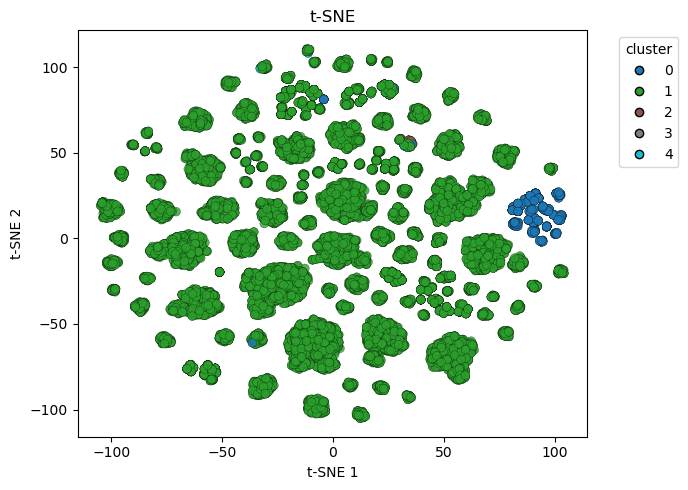

In [39]:
agg = AgglomerativeClustering(
    n_clusters=5,
    linkage='average',
    metric='precomputed'  
)
y_train = agg.fit_predict(X_train_gower)
tsne_plot(X_train, y=y_train)

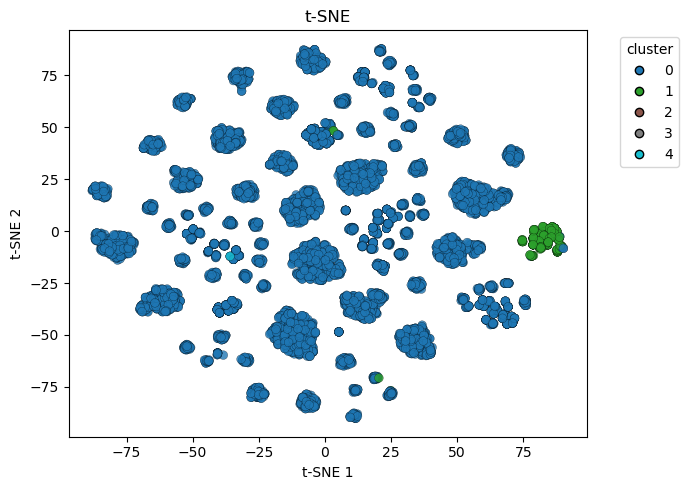

In [40]:
agg_test = AgglomerativeClustering(
    n_clusters=5,
    linkage='average',
    metric='precomputed'
)
y_test = agg_test.fit_predict(X_test_gower)
tsne_plot(X_test, y=y_test)


Wyniki nawet gorsze niż KMeans, darujemy sobie dalszą analizę

## DBScan

Train

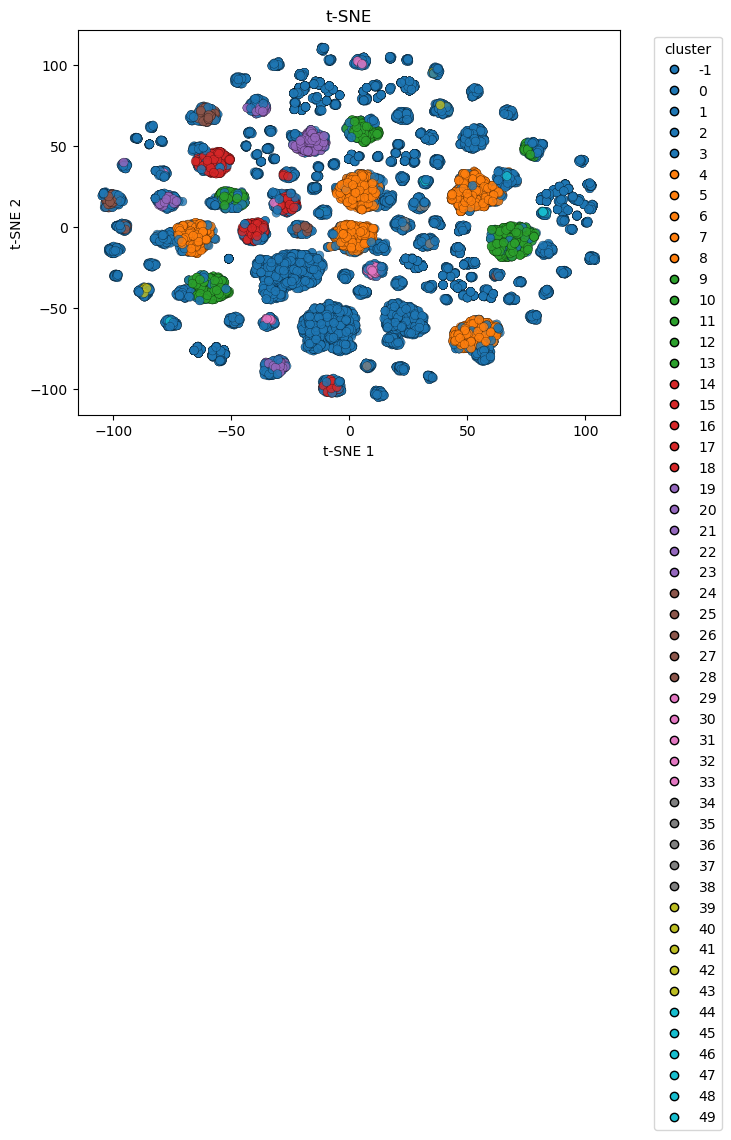

In [41]:
params={'eps': 0.03, 'min_samples': 10, 'metric' : 'precomputed'}

dbscan = DBSCAN(**params) 
predicted_train=dbscan.fit_predict(X_train_gower)

tsne_plot(X_train, y=predicted_train)


Test

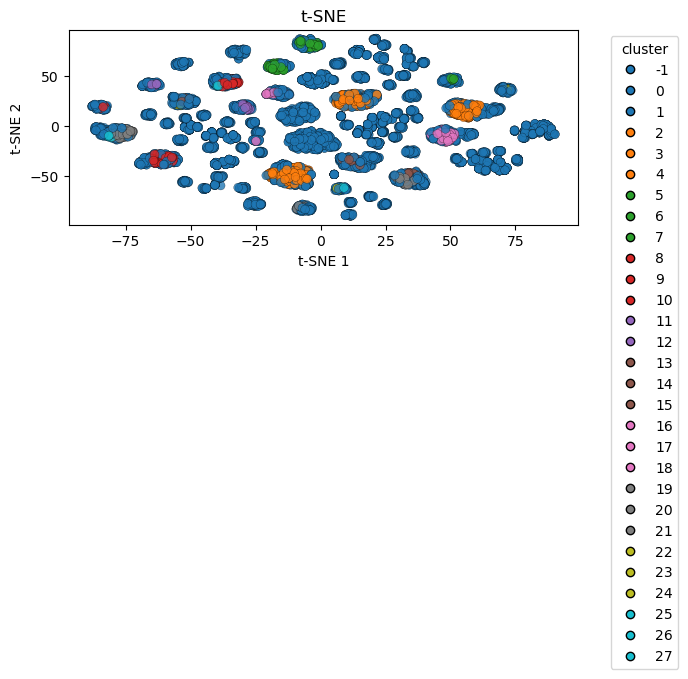

In [42]:
predicted_test = dbscan.fit_predict(X_test_gower)
tsne_plot(X_test, y=predicted_test)

Wyniki bardzo dziwne, darujemy sobie interpretację

## Dla walidacji


In [61]:
def loadGMM(filepath: str):
    with open(filepath, 'rb') as f:
        gmm = pickle.load(f)
    print(f"GMM model loaded from {filepath!r}")
    return gmm

In [62]:
df_validation=pd.read_csv("data/TransformedData/val.csv")
Famd=load_famd("data/TransformedData/famd_model.pkl")
gmm= loadGMM("data/TransformedData/gmm_model.pkl")
X_val=Famd.transform(df_validation)
predicted_validation = gmm.predict(X_val)

FAMD model loaded from 'data/TransformedData/famd_model.pkl'
GMM model loaded from 'data/TransformedData/gmm_model.pkl'


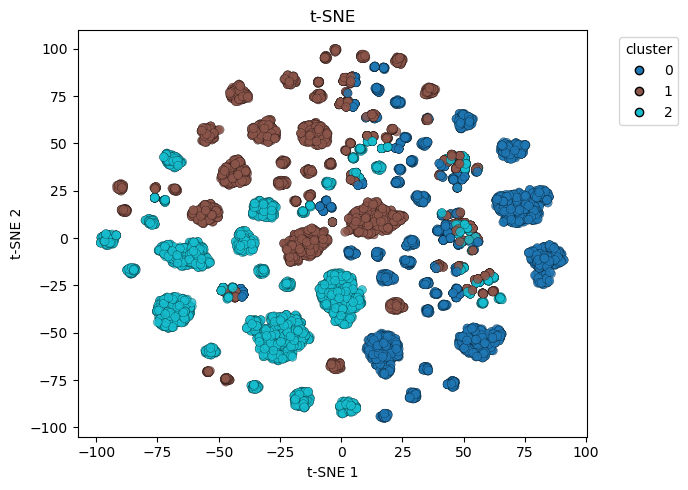

In [63]:
tsne_plot(X_val,predicted_validation)